### IPCC regions 

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import matplotlib as mpl
import numpy as np
from shapely.geometry import Point
#from mpl_toolkits.basemap import Basemap
# Set Matplotlib to use a non-interactive backend to avoid Tkinter issues
#import matplotlib
import geoplot
#import cartopy.crs as ccrs


plt.rcParams.update({
     "font.family": "Arial",
     "font.size": 10,
     "axes.labelsize": 10,
     "axes.titlesize": 12,
     "xtick.labelsize": 9,
     "ytick.labelsize": 9,
     "figure.dpi": 300,
     "savefig.dpi": 600,
     "legend.title_fontsize": 10,
     "legend.fontsize": 9,
     "savefig.bbox": "tight",
     "savefig.pad_inches": 0.05,
  })

In [2]:
# Load data
glohydrores_file = "/home/shah0012/GloHydroRes/Output_data/GloHydroRes_vs2.xlsx"
glohydrores_df = pd.read_excel(glohydrores_file, sheet_name="Data")
IPCC_climate_regions = gpd.read_file("/scratch/shah0012/hybrid_hydropower_model/data/IPCC_climate_regions/IPCC-WGI-reference-regions-v4.shp")

# Create geodataframe for hydropower plants
geometry = [Point(xy) for xy in zip(glohydrores_df['plant_lon'], glohydrores_df['plant_lat'])]
glohydrores_gdf = gpd.GeoDataFrame(glohydrores_df, geometry=geometry, crs=IPCC_climate_regions.crs)

# Join hydropower plants data with IPCC regions
glohydrores_gdf_ipcc_region_data_joined = gpd.sjoin(glohydrores_gdf, IPCC_climate_regions, how='left', predicate='within')

# Calculate installed capacity by IPCC region
ipcc_group_installed_capacity = glohydrores_gdf_ipcc_region_data_joined.groupby("Acronym")["capacity_mw"].sum().reset_index()
ipcc_group_installed_capacity["capacity_gw"] = ipcc_group_installed_capacity["capacity_mw"] / 1000
ipcc_group_installed_capacity.sort_values(by="capacity_gw", ascending=False, inplace=True)
ipcc_group_installed_capacity["region_name"] = ipcc_group_installed_capacity["Acronym"].map(
    dict(zip(IPCC_climate_regions["Acronym"], IPCC_climate_regions["Name"]))
)


# Select top 12 regions by installed capacity
top_regions = ipcc_group_installed_capacity.head(12)["Acronym"].tolist()
top_regions_df = ipcc_group_installed_capacity[ipcc_group_installed_capacity["Acronym"].isin(top_regions)]
top_regions_gdf = IPCC_climate_regions[IPCC_climate_regions["Acronym"].isin(top_regions)]


/home/shah0012/.conda/envs/python_env/lib/python3.7/site-packages/geoplot/geoplot.py:885: ShapelyDeprecationWarning: Iteration over multi-part geometries is deprecated and will be removed in Shapely 2.0. Use the `geoms` property to access the constituent parts of a multi-part geometry.
  for subgeom in geom:
/home/shah0012/.conda/envs/python_env/lib/python3.7/site-packages/geopandas/plotting.py:123: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  return PathPatch(path, **kwargs)
findfont: Font family ['Arial'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Arial'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Arial'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Arial'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Arial'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Arial'] not found. Falling back to DejaVu Sans.


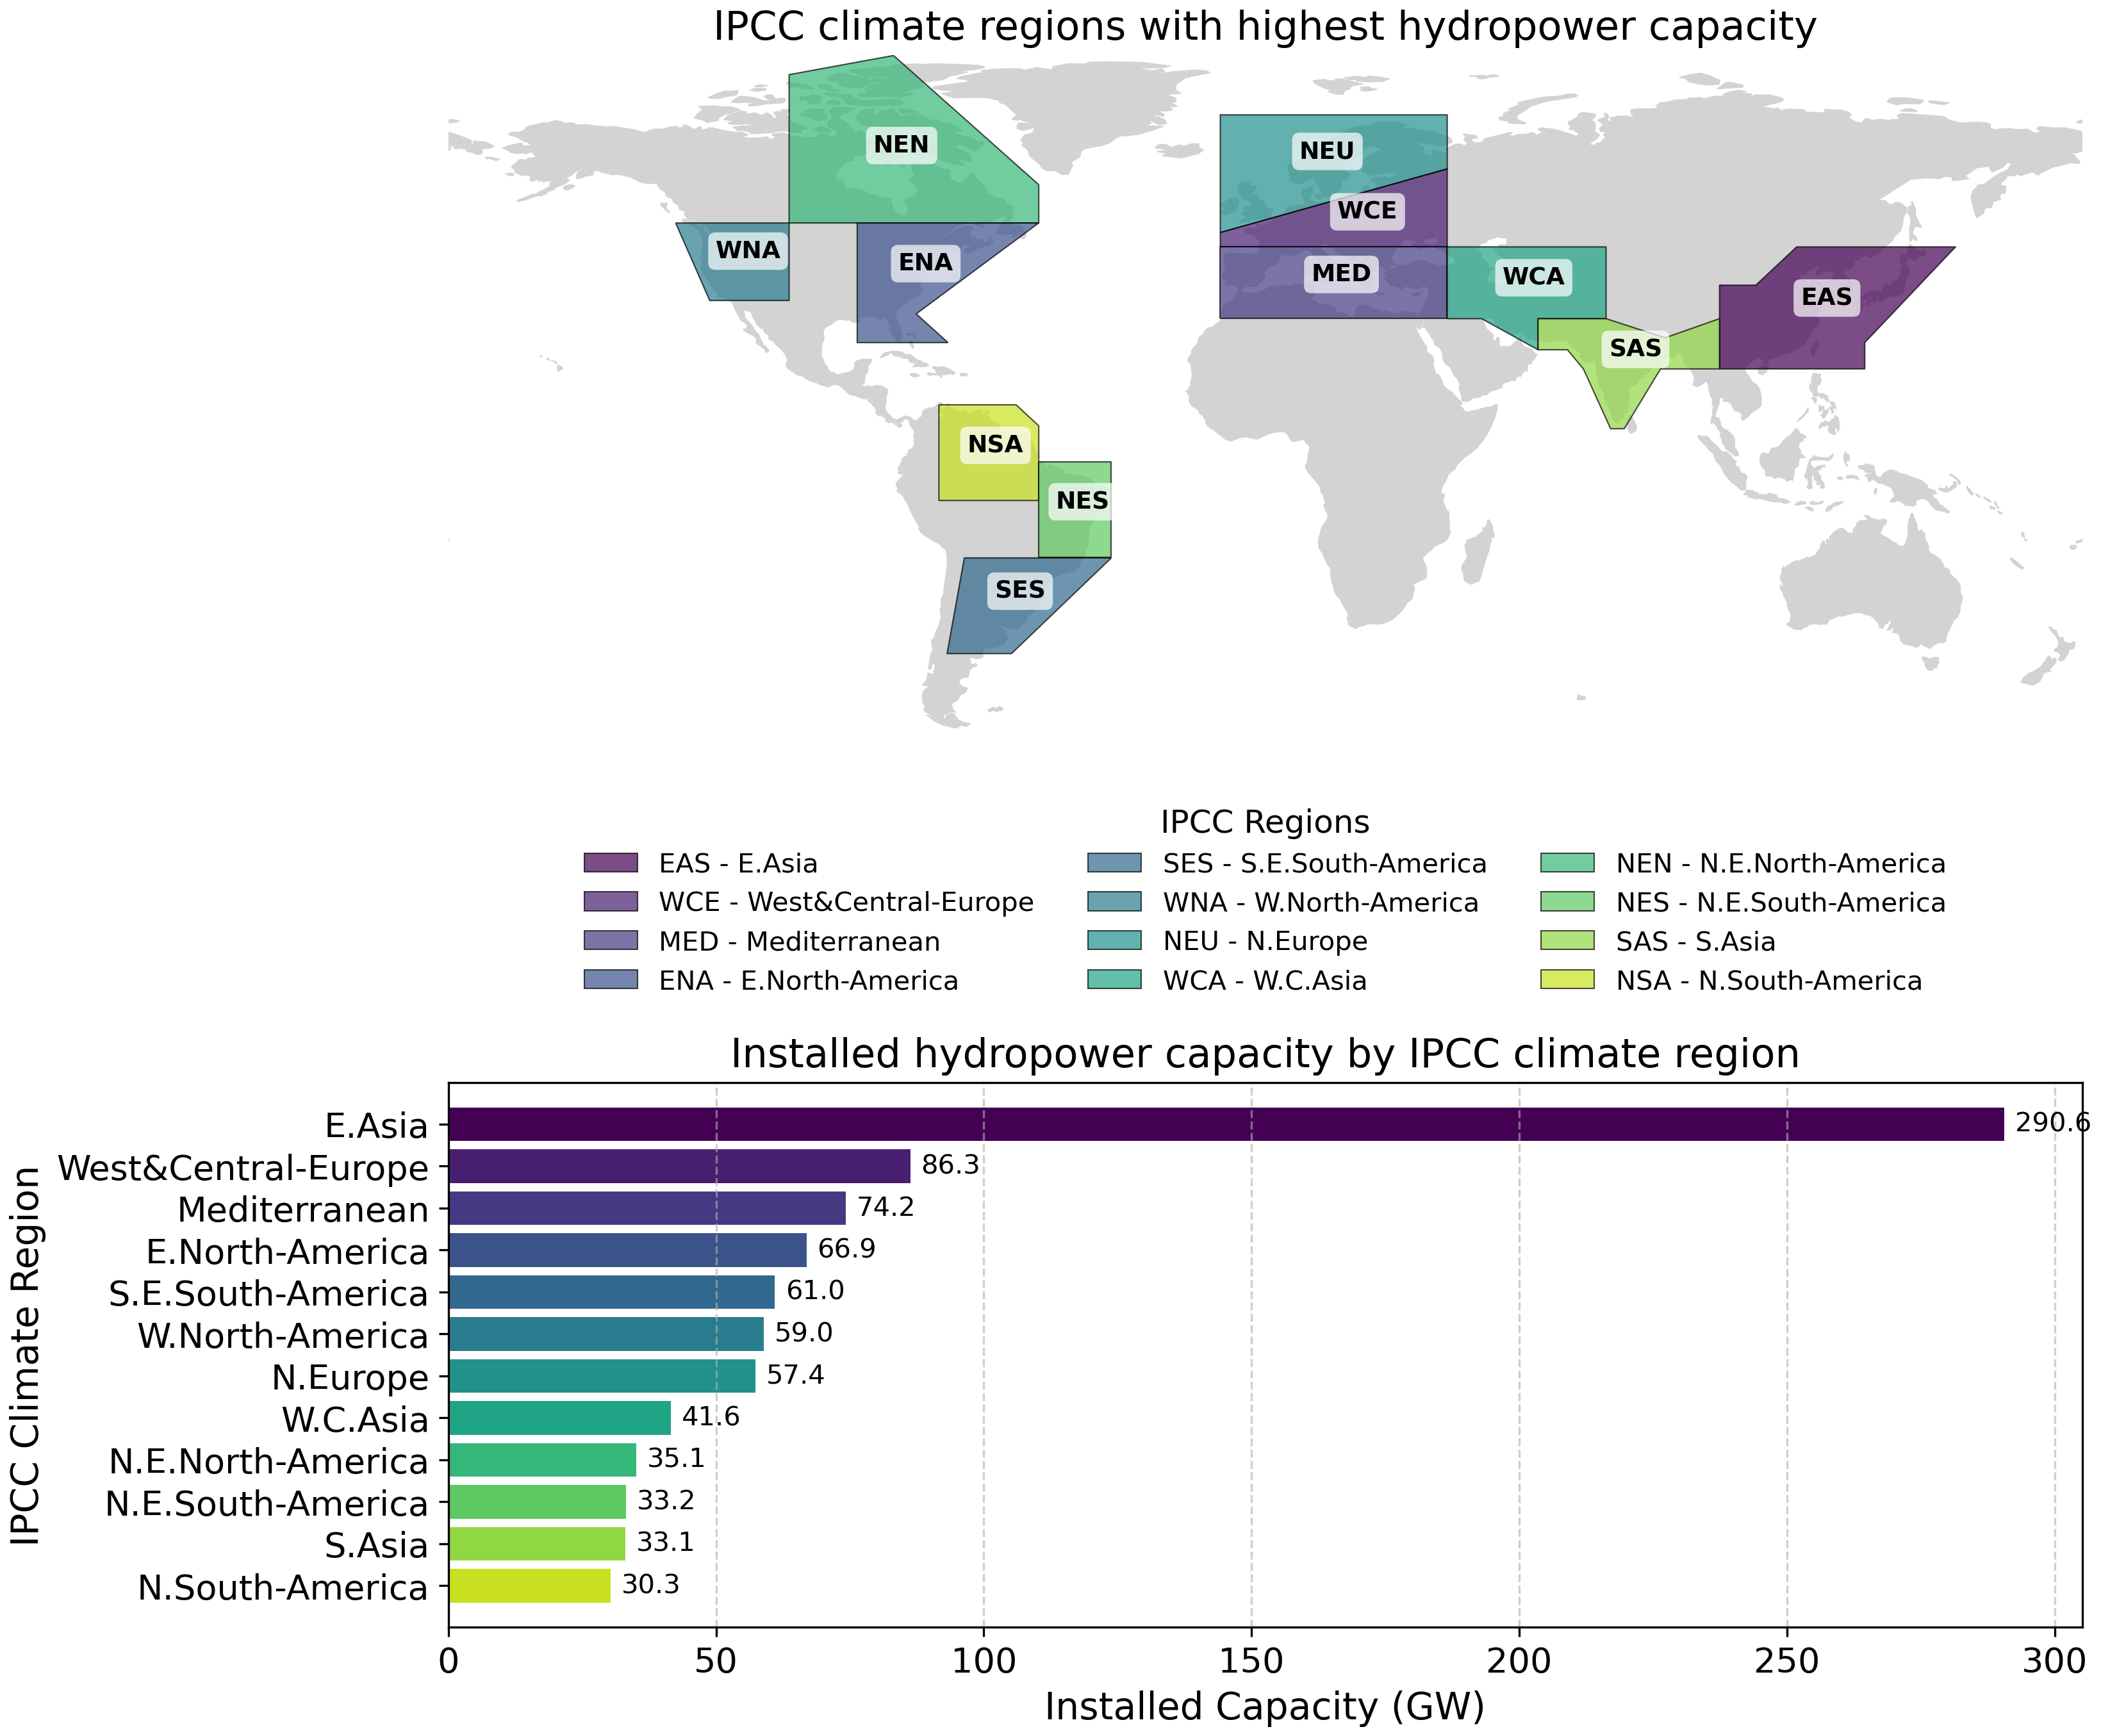

In [ ]:

# Create a color map for the regions
num_regions = len(top_regions)
cmap = plt.cm.viridis
norm = mpl.colors.Normalize(vmin=0, vmax=num_regions-1)
region_colors = {region: cmap(i/num_regions) for i, region in enumerate(top_regions_df["Acronym"])}


# Create figure with GridSpec - adjust figure size to accommodate legends better
fig = plt.figure(figsize=(10, 10), dpi=300)
gs = GridSpec(2, 1, height_ratios=[3, 2],  hspace=0.4)  # Increased hspace

# First subplot - Map of IPCC regions
ax1 = fig.add_subplot(gs[0])

# Plot base world map
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
#world.plot(ax=ax1, color='lightgrey', edgecolor='grey', linewidth=0.3)
geoplot.polyplot(world, ax=ax1, color='lightgrey',  edgecolor='grey', linewidth=0.3)

# Plot colored regions
for i, row in top_regions_gdf.iterrows():
    color = region_colors[row['Acronym']]
    top_regions_gdf.loc[[i]].plot(ax=ax1, color=color, alpha=0.7, edgecolor='black', linewidth=0.5)

    # Get centroid for label placement
    centroid = row['geometry'].centroid
    ax1.annotate(row['Acronym'], xy=(centroid.x, centroid.y),
                 xytext=(3, 3), textcoords="offset points",
                 fontsize=9, fontweight='bold', ha='center', va='center',
                 bbox=dict(boxstyle="round,pad=0.3", fc='white', ec='none', alpha=0.7))

pos = ax1.get_position()
ax1.set_position([pos.x0 - 0.05, pos.y0, pos.width + 0.08, pos.height])

#ax1.margins(0)

# Set map boundaries
ax1.set_xlim(-180, 180)
ax1.set_ylim(-60, 85)
ax1.set_title("IPCC climate regions with highest hydropower capacity", fontsize = 15)

# Create a separate legend axis for the regions instead of adding to main plot
legend_handles = []
for acronym, color in region_colors.items():
    region_name = ipcc_group_installed_capacity[ipcc_group_installed_capacity["Acronym"] == acronym]["region_name"].values[0]
    legend_handles.append(mpl.patches.Patch(facecolor=color, alpha=0.7, edgecolor='black', linewidth=0.5,
                                          label=f"{acronym} - {region_name}"))


ax1.legend(handles=legend_handles, loc='upper center', bbox_to_anchor=(0.5, -0.05),
          ncol=3, title="IPCC Regions", frameon=False, framealpha=0.8, fontsize= 10,  title_fontsize=12)


# Second subplot - Bar chart of installed capacity
ax2 = fig.add_subplot(gs[1])

# Extract just the top 12 regions and reverse order for better visualization
plot_data = top_regions_df.iloc[::-1]

# Create the bar chart with the same colors as the map
colors = [region_colors[region] for region in plot_data["Acronym"]]
bars = ax2.barh(plot_data["region_name"], plot_data["capacity_gw"], color=colors)

# Add data labels to the bars
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax2.text(width + 2, bar.get_y() + bar.get_height()/2,
             f"{width:.1f}", ha='left', va='center', fontsize=10)

ax2.set_xlabel("Installed Capacity (GW)", fontsize = 14)
ax2.set_ylabel("IPCC Climate Region", fontsize = 14)
ax2.set_title("Installed hydropower capacity by IPCC climate region", fontsize = 15)
ax2.tick_params(axis='both', labelsize=13)

# Add grid to bar chart for better readability
ax2.grid(axis='x', linestyle='--', alpha=0.6)

# Manually adjust layout instead of using tight_layout
plt.subplots_adjust(left=0.1, right=0.95, top=0.95, bottom=0.1)


# Save the figure
plt.savefig("/home/shah0012/Hydropower_hybrid_model/figures/IPCC_Regions_Installed_Capacity.png", dpi=600, bbox_inches='tight')
plt.savefig("/home/shah0012/Hydropower_hybrid_model/figures/IPCC_Regions_Installed_Capacity.pdf", format='pdf', dpi=600, bbox_inches='tight')
plt.show()
